In [2]:
import gdist
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import nibabel as nib
import os.path as op

# numrefields_copy2 works !
with tf.device('/cpu:0'):
    from fugw.mappings import FUGW
from fugw.utils import load_mapping, save_mapping

from mpl_toolkits.axes_grid1 import make_axes_locatable
from nilearn import datasets, image, plotting, surface

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
grad_folder = 'derivatives/gradients'


Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB



2023-10-25 17:16:03.205693: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-10-25 17:16:03.207028: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/mrenke/mambaforge/envs/numrefields_copy2/lib/python3.10/site-packages/ot/backend.py:2998: UserWarning: To use TensorflowBackend, you need to activate the tensorflow numpy API. You can activate it by running: 
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()
  register_backend(TensorflowBackend())


231024-15:17:27,612 nipype.utils WARNING:
	 A newer version (1.8.4) of nipy/nipype is available. You are using 1.8.3


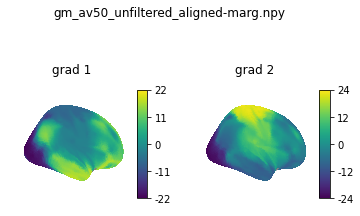

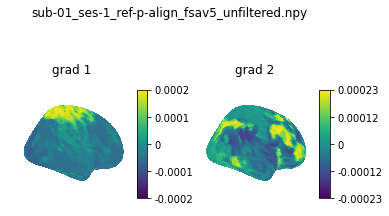

In [2]:
from utils_02 import plot_GM12_from_sum_npfile
from os import listdir

subList_npFiles = [f for f in listdir(op.join(bids_folder, grad_folder)) if f[0:4] == 'sub-' and len(f)==45]

plot_GM12_from_sum_npfile()
plot_GM12_from_sum_npfile(file=subList_npFiles[0])

In [3]:
gm_target_g1 = nib.load(op.join(bids_folder,grad_folder,'sub-average_cmunfil_01','ses-1','sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage5_hemi-L_grad1_noParcel.surf.gii')).agg_data()
gm_target_g2 = nib.load(op.join(bids_folder,grad_folder,'sub-average_cmunfil_01','ses-1','sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage5_hemi-L_grad2_noParcel.surf.gii')).agg_data()

gm_source_g1 = nib.load(op.join(bids_folder,grad_folder,'sub-01','ses-1','sub-01_ses-1_task-risk_space-fsaverage5_hemi-L_grad1_noParcel.surf.gii')).agg_data() #subList_npFiles[0]
gm_source_g2 = nib.load(op.join(bids_folder,grad_folder,'sub-01','ses-1','sub-01_ses-1_task-risk_space-fsaverage5_hemi-L_grad2_noParcel.surf.gii')).agg_data() #subList_npFiles[0]



231025-17:16:14,917 nipype.utils WARNING:
	 A newer version (1.8.4) of nipy/nipype is available. You are using 1.8.3


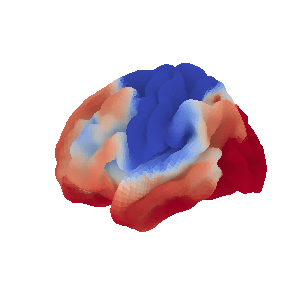

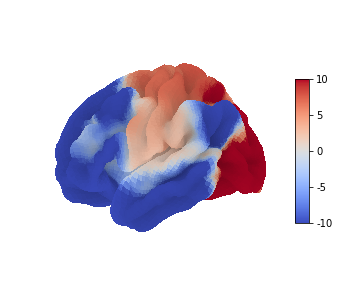

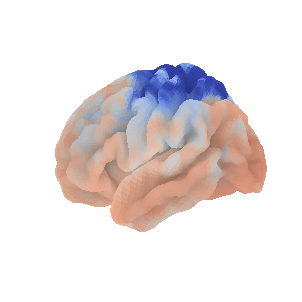

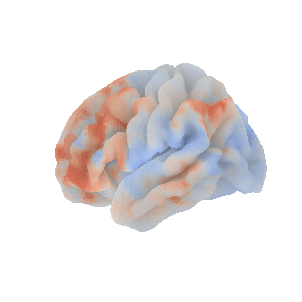

In [4]:
from utils_02 import plot_surface_map

fsaverage = datasets.fetch_surf_fsaverage()

plot_surface_map(gm_target_g1, fsaverage,vmax=10, vmin=-10, colorbar=False)
plot_surface_map(gm_target_g2, fsaverage,vmax=10, vmin=-10, colorbar=True)

plot_surface_map(-gm_source_g1,fsaverage, vmax=10, vmin=-10, colorbar=False)
plot_surface_map(gm_source_g2,fsaverage, vmax=10, vmin=-10, colorbar=False)


### Computing geometry arrays

In [47]:
def compute_geometry_from_mesh(mesh_path):
    """Util function to compute matrix of geodesic distances of a mesh."""
    (coordinates, triangles) = surface.load_surf_mesh(mesh_path)
    geometry = gdist.local_gdist_matrix(
        coordinates.astype(np.float64), triangles.astype(np.int32)
    ).toarray()

    return geometry


In [48]:
fsaverage_pial_left_geometry = compute_geometry_from_mesh(
    fsaverage.pial_left
)
np.save(op.join(bids_folder,grad_folder,'fsaverage_pial_left_geometry.npy'),fsaverage_pial_left_geometry)

In [6]:
fsaverage_pial_left_geometry = np.load(op.join(bids_folder,grad_folder,'fsaverage_pial_left_geometry.npy'))

In [7]:
source_geometry = fsaverage_pial_left_geometry
target_geometry = fsaverage_pial_left_geometry
source_geometry.shape

(10242, 10242)

### Normalizing features and geometries


In [10]:
source_features = np.array([-gm_source_g1, gm_source_g2])
target_features = np.array([gm_target_g1, gm_source_g2])
source_features.shape

(2, 10242)

In [9]:
source_features_normalized = source_features / np.linalg.norm(source_features, axis=1).reshape(-1, 1)
target_features_normalized = target_features / np.linalg.norm(target_features, axis=1).reshape(-1, 1)
source_geometry_normalized = source_geometry / np.max(source_geometry)
target_geometry_normalized = target_geometry / np.max(target_geometry)

## Training the mapping

In [11]:
alpha = 0.5
rho = 1
eps = 1e-4
mapping = FUGW(alpha=alpha, rho=rho, eps=eps)

In [ ]:
solver = "sinkhorn"
_ = mapping.fit(
    source_features_normalized,
    target_features_normalized,
    source_geometry=source_geometry_normalized,
    target_geometry=target_geometry_normalized,
    solver=solver,
    solver_params={
        "nits_bcd": 3,
    },
    verbose=True,
)

In [20]:
mm_mapping = FUGW(alpha=alpha, rho=rho, eps=eps)

_ = mm_mapping.fit(
    source_features_normalized,
    target_features_normalized,
    source_geometry=source_geometry_normalized,
    target_geometry=target_geometry_normalized,
    solver="mm",
    solver_params={
        "nits_bcd": 5,
        "tol_bcd": 1e-10,
        "tol_uot": 1e-10,
    },
    verbose=True,
)

[16:00:54] Validation data for feature maps is not provided. Using training data instead.              ]8;id=489975;file:///Users/mrenke/git/fugw/src/fugw/mappings/dense.py\dense.py]8;;\:]8;id=134574;file:///Users/mrenke/git/fugw/src/fugw/mappings/dense.py#199\199]8;;\

           Validation data for anatomical kernels is not provided. Using training data instead.        ]8;id=941578;file:///Users/mrenke/git/fugw/src/fugw/mappings/dense.py\dense.py]8;;\:]8;id=463818;file:///Users/mrenke/git/fugw/src/fugw/mappings/dense.py#226\226]8;;\

/Users/mrenke/mambaforge/envs/numrefields_copy2/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[16:01:14] BCD step 1/5    FUGW loss:      nan     Validation loss:        nan                         ]8;id=156071;file:///Users/mrenke/git/fugw/src/fugw/solvers/dense.py\dense.py]8;;\:]8;id=555121;file:///Users/mrenke/git/fugw/src/fugw/solvers/dense.py#521\521]8;;\

           There is NaN in coupling                                                                    ]8;id=478931;file:///Users/mrenke/git/fugw/src/fugw/solvers/dense.py\dense.py]8;;\:]8;id=196553;file:///Users/mrenke/git/fugw/src/fugw/solvers/dense.py#541\541]8;;\

In [1]:
source_features_normalized

NameError: name 'source_features_normalized' is not defined

## convert r2/mu-maps decoder into surface-format

In [14]:
file_r2 ='/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.denoise/sub-01/ses-1/func/sub-01_ses-1_desc-r2.optim_space-T1w_pars.nii.gz'
file_mu ='/Volumes/mrenkeED/data/ds-stressrisk/derivatives/encoding_model.denoise/sub-01/ses-1/func/sub-01_ses-1_desc-mu.optim_space-T1w_pars.nii.gz'

image_paths = [file_r2, file_mu]


In [15]:
def load_images_and_project_to_surface(image_paths):
    """Util function for loading and projecting volumetric images."""
    images = [image.load_img(img) for img in image_paths]
    surface_images = [
        np.nan_to_num(surface.vol_to_surf(img, fsaverage.pial_left))
        for img in images
    ]

    return np.stack(surface_images)


In [16]:
source_decod_params = load_images_and_project_to_surface(image_paths)

/Users/mrenke/mambaforge/envs/numrefields_copy2/lib/python3.10/site-packages/nilearn/surface/surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/mrenke/mambaforge/envs/numrefields_copy2/lib/python3.10/site-packages/nilearn/surface/surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


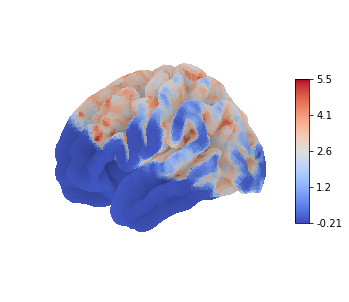

In [19]:
plot_surface_map(source_decod_params[1], fsaverage=fsaverage)